## Term Deposit Prediction

### Goal(s):

Predict if the customer will subscribe (yes/no) to a term deposit (variable y)

### Success Metric(s):

Hit 81% or above accuracy by evaluating with 5-fold cross validation and reporting the average performance score.

### Current Challenges:

We are also interested in finding customers who are more likely to buy the investment product. Determine the segment(s) of customers our client should prioritize.

What makes the customers buy? Tell us which feature we should be focusing more on.

In [2]:
#Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
from sklearn.preprocessing import QuantileTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, RocCurveDisplay, roc_auc_score, f1_score
from imblearn.over_sampling import SMOTE

In [3]:
# Import data as pandas dataframe
term_dep = pd.read_csv("term-deposit-marketing-2020.csv")

## Exploratory data analysis

In [5]:
term_dep.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        40000 non-null  int64
 1   job        40000 non-null  str  
 2   marital    40000 non-null  str  
 3   education  40000 non-null  str  
 4   default    40000 non-null  str  
 5   balance    40000 non-null  int64
 6   housing    40000 non-null  str  
 7   loan       40000 non-null  str  
 8   contact    40000 non-null  str  
 9   day        40000 non-null  int64
 10  month      40000 non-null  str  
 11  duration   40000 non-null  int64
 12  campaign   40000 non-null  int64
 13  y          40000 non-null  str  
dtypes: int64(5), str(9)
memory usage: 4.3 MB


In [6]:
term_dep.describe()

,age,balance,day,duration,campaign
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,40.544600,1274.277550,16.017225,254.824300,2.882175
std,9.641776,2903.769716,8.278127,259.366498,3.239051
min,19.000000,-8019.000000,1.000000,0.000000,1.000000
25%,33.000000,54.000000,8.000000,100.000000,1.000000
50%,39.000000,407.000000,17.000000,175.000000,2.000000
75%,48.000000,1319.000000,21.000000,313.000000,3.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000


In [7]:
term_dep.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,no


In [8]:
term_dep["education"].value_counts()

education
secondary    20993
tertiary     11206
primary       6270
unknown       1531
Name: count, dtype: int64

In [9]:
term_dep["contact"].value_counts()

contact
cellular     24914
unknown      12765
telephone     2321
Name: count, dtype: int64

In [10]:
term_dep["y"].value_counts()

y
no     37104
yes     2896
Name: count, dtype: int64

Target is highly imbalanced

The aim of this project is to predict if a customer will subscribe to term deposit before contacting them. In this regard, "campaign" becomes a posterior feature since all customers in the given dataset were contacted at least once. Therefore, excluding "campaign" from further analysis is advised.

In [13]:
num_cols = ["age", "balance", "day", "duration"]
cat_cols = ["job", "marital", "education", "default", "housing", "loan", "contact", "month"]

### Numeric variables

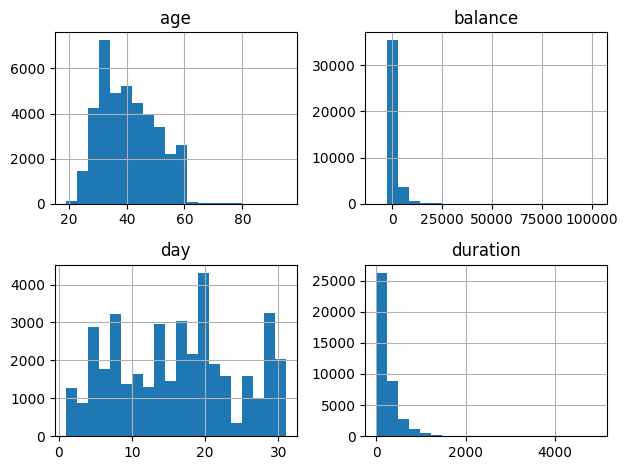

In [15]:
term_dep[num_cols].hist(bins=20)
plt.tight_layout()
plt.show()

Features "balance and "duration" are highly skewed

In [17]:
term_dep[num_cols].skew()

age         0.436080
balance     8.259236
day         0.067930
duration    3.165307
dtype: float64

Consider log1p transformation of to reduce skewness.

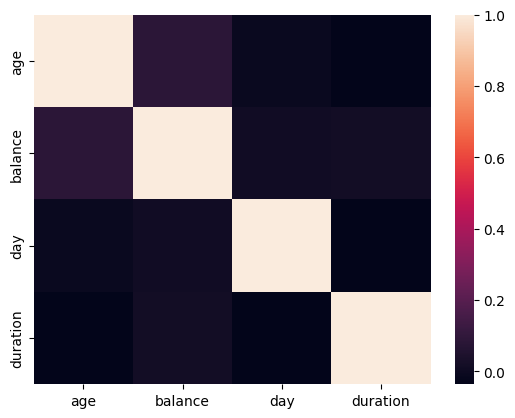

In [19]:
sns.heatmap(term_dep[num_cols].corr())
plt.show()

In [20]:
term_dep[num_cols].corr()

,age,balance,day,duration
age,1.000000,0.081517,-0.011689,-0.036270
balance,0.081517,1.000000,0.011662,0.014072
day,-0.011689,0.011662,1.000000,-0.032983
duration,-0.036270,0.014072,-0.032983,1.000000


Weak correlation among numeric variables

### Non-numeric variables

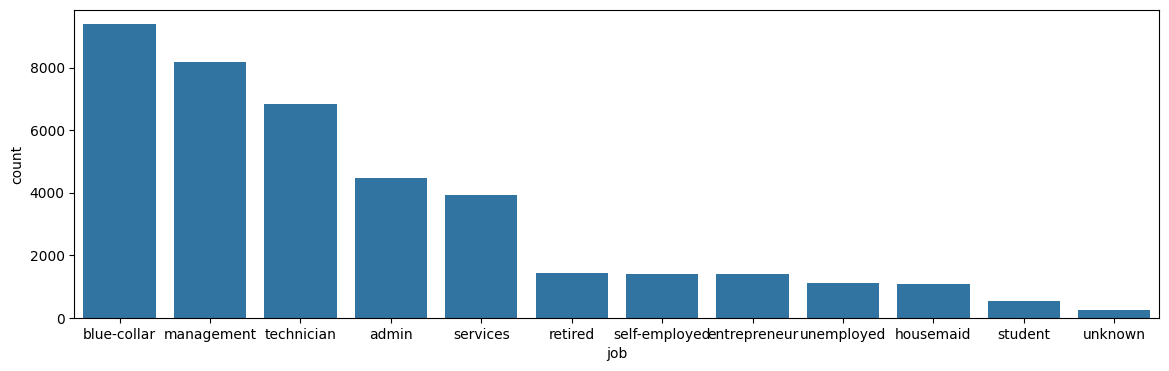

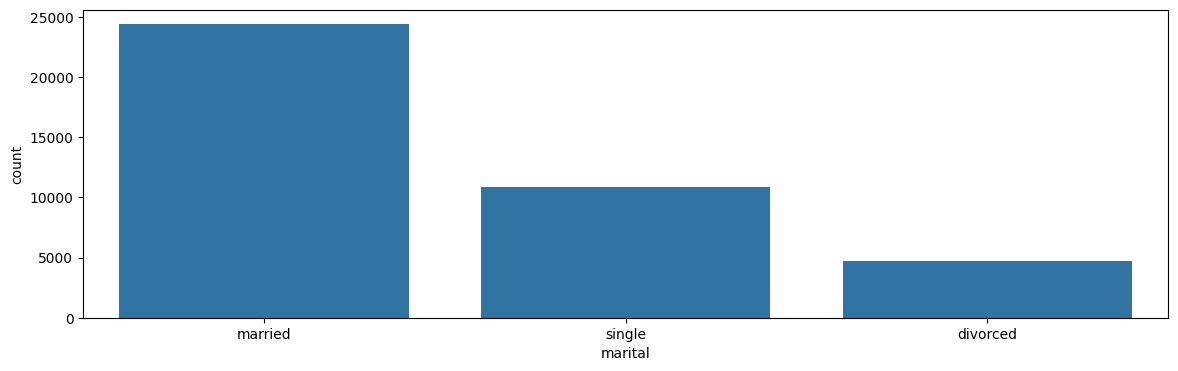

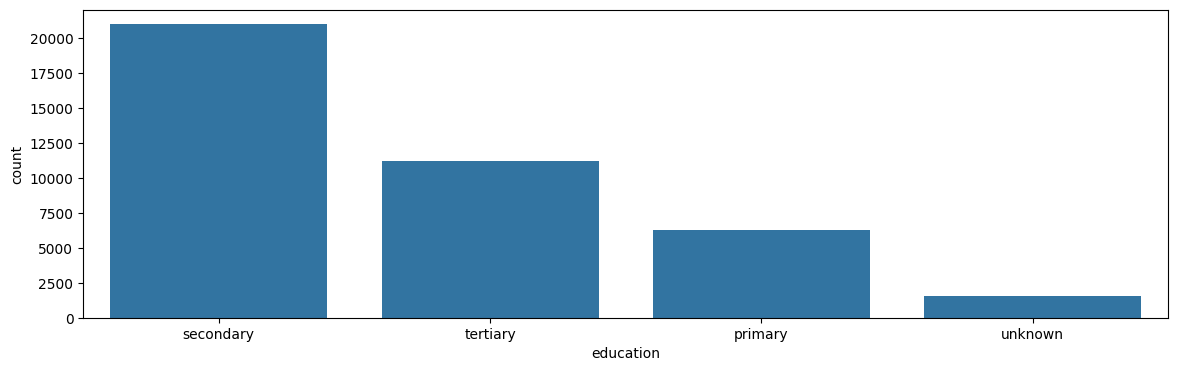

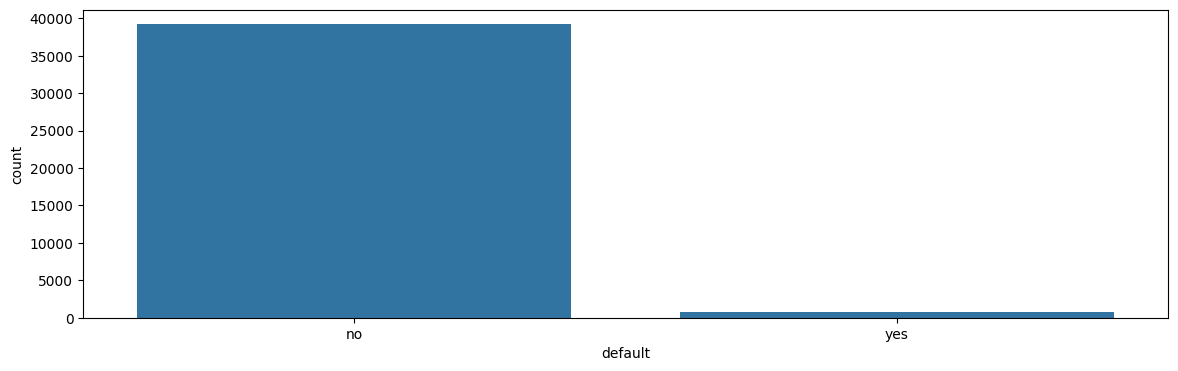

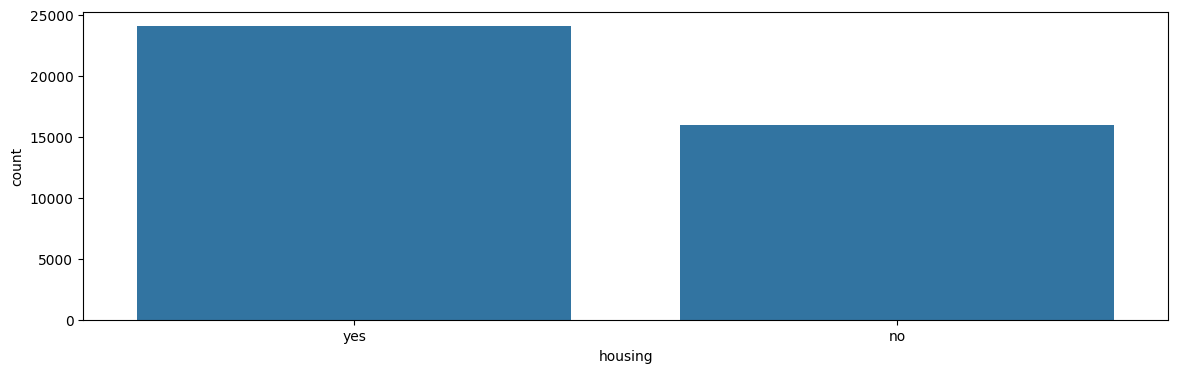

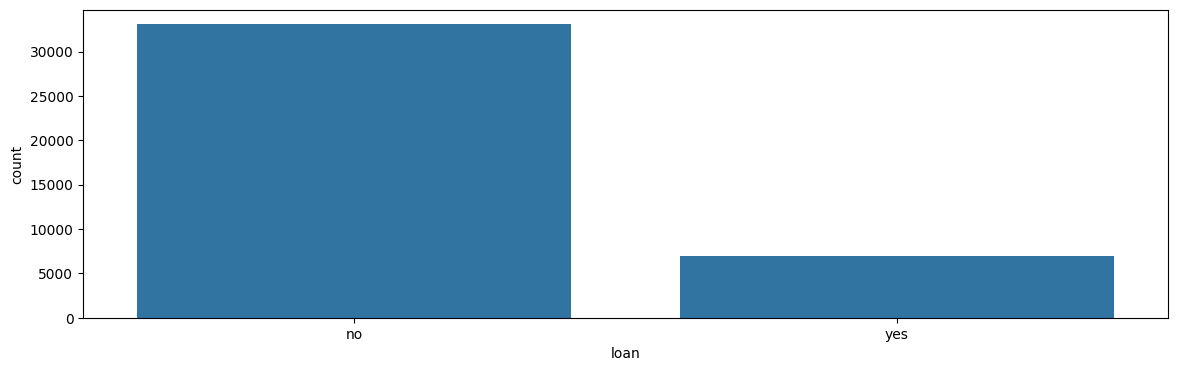

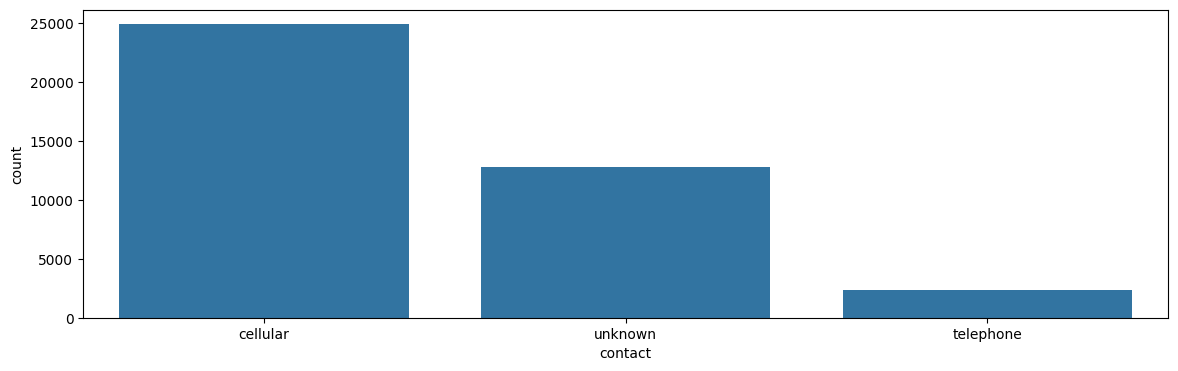

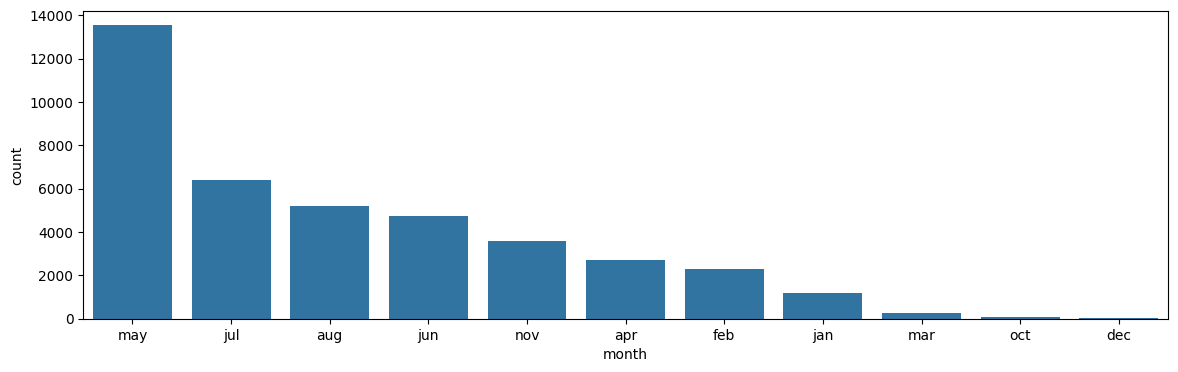

In [23]:
for col in cat_cols:
    plt.figure(figsize=(14,4))
    sns.countplot(x=col, data=term_dep, order=term_dep[col].value_counts().index)
    plt.show()

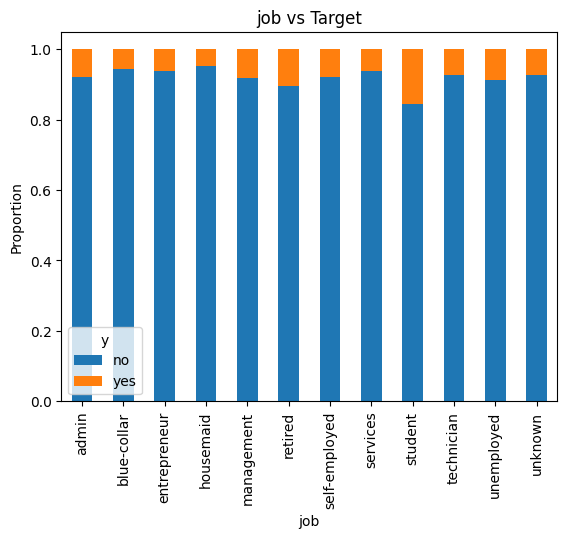

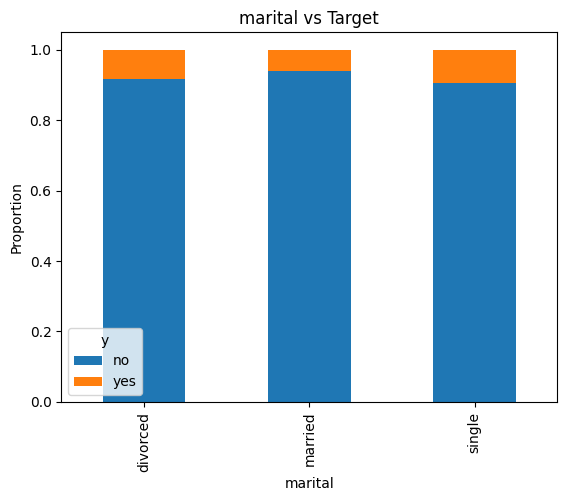

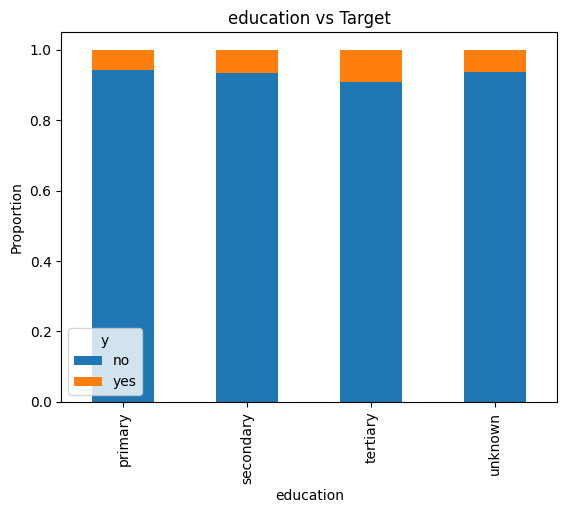

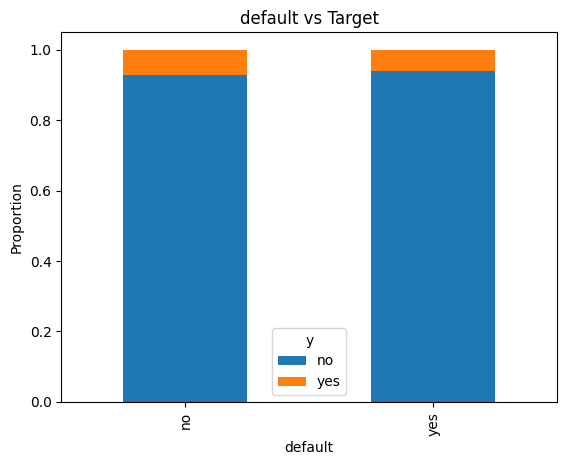

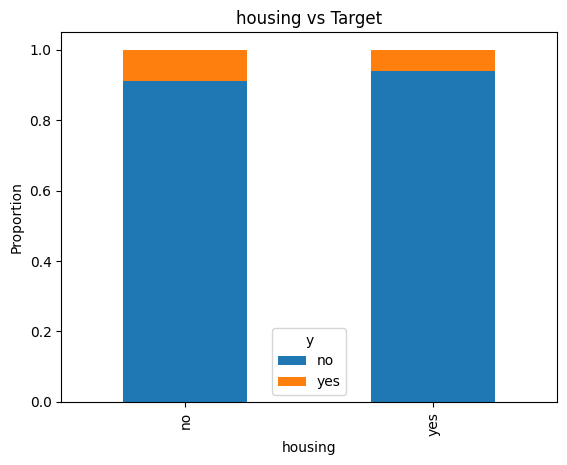

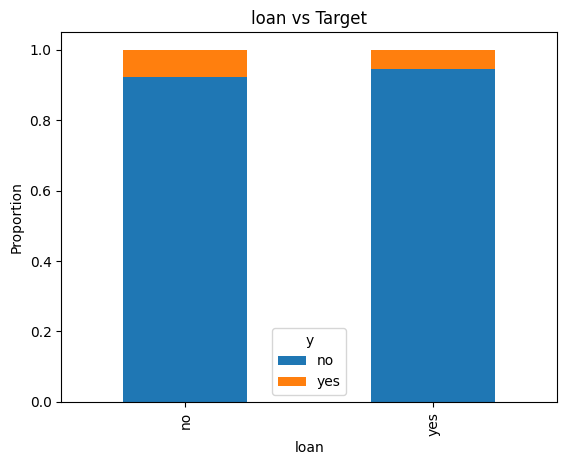

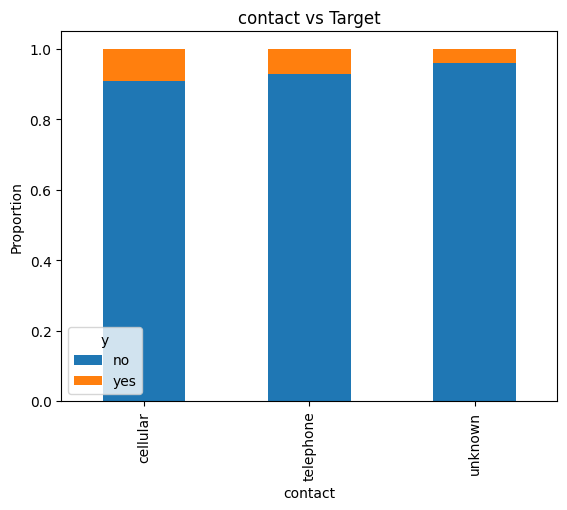

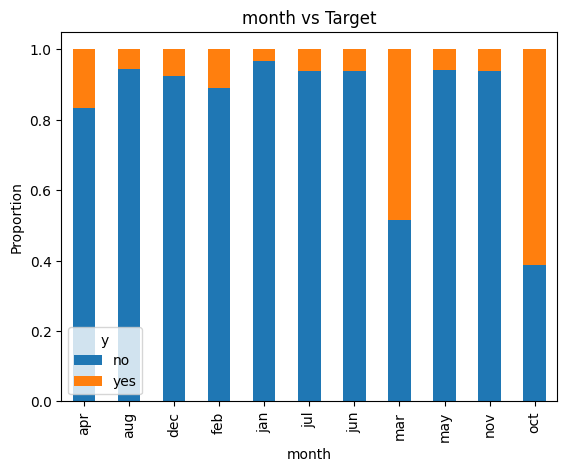

In [24]:
for col in cat_cols:
    cross_tab = pd.crosstab(term_dep[col], term_dep["y"], normalize = "index")
    cross_tab.plot(kind="bar", stacked=True)
    plt.title(f"{col} vs Target")
    plt.ylabel("Proportion")
    plt.show()

Months of March and October show the strongest influence on customer opting for a term deposit. Other features may look like having much lesser influence. However, highly imbalanced nature of the target "y" requires a thorough analysis.

### Target variable

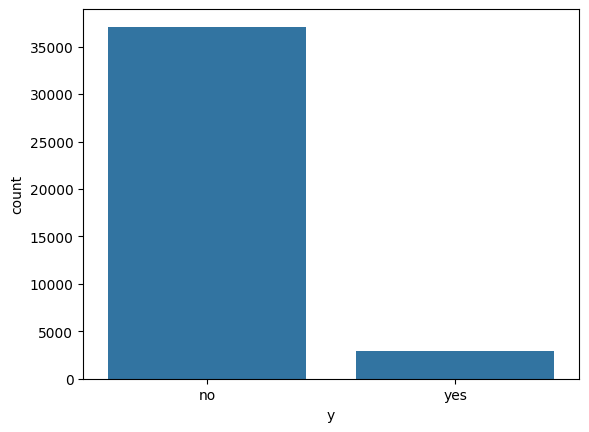

In [27]:
sns.countplot(x="y", data=term_dep)
plt.show()

In [28]:
for col in cat_cols:
    contingency = pd.crosstab(term_dep[col], term_dep['y'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f"{col} p-value: {p}")

job p-value: 1.6761348063575326e-26
marital p-value: 3.091030601234065e-30
education p-value: 8.061910845440868e-21
default p-value: 0.21373529827845061
housing p-value: 2.048342664339848e-27
loan p-value: 6.395487199647575e-10
contact p-value: 7.242046790893985e-71
month p-value: 0.0


Strong statistical evidence that job, marital, education, housing, loan, contact, and month impact "y".

## Data preprocessing

In [31]:
term_dep_original = term_dep.copy()

In [32]:
# log transformation of duration and campaign features

term_dep["duration_log"] = np.log1p(term_dep["duration"])
#term_dep["campaign_log"] = np.log1p(term_dep["campaign"])

In [33]:
# Since balance contains many negative values, we will use quantile transformation. 
# This choice is based on the assumption that the model only needs to know in which bracket the balance falls instead of the actual number

qt = QuantileTransformer(output_distribution='normal')
term_dep["balance_qt"] = qt.fit_transform(term_dep[["balance"]])

In [34]:
term_dep.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'y',
       'duration_log', 'balance_qt'],
      dtype='str')

In [35]:
new_columns = ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'day', 'month', 'y', 'duration_log', 'balance_qt']

In [36]:
term_new = term_dep[new_columns]

In [37]:
# One-hot encoding of non-numeric faetures
term_enc = pd.get_dummies(term_new, drop_first=True, dtype=int)

In [38]:
term_enc.head()

,age,day,duration_log,balance_qt,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,...,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,y_yes
0,58,5,5.568345,0.966965,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
1,44,5,5.023881,-0.761353,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,33,5,4.343805,-0.926176,0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,47,5,4.532599,0.750677,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,33,5,5.293305,-0.939747,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [39]:
term_enc.describe()

,age,day,duration_log,balance_qt,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,...,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,y_yes
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,...,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,40.544600,16.017225,5.148957,0.001976,0.234575,0.035125,0.027175,0.204150,0.035925,0.035350,...,0.000325,0.057400,0.029400,0.159500,0.118350,0.006450,0.338300,0.089950,0.002000,0.072400
std,9.641776,8.278127,0.927780,0.995872,0.423738,0.184098,0.162595,0.403084,0.186106,0.184665,...,0.018025,0.232608,0.168927,0.366146,0.323026,0.080053,0.473137,0.286114,0.044677,0.259152
min,19.000000,1.000000,0.000000,-5.199338,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,33.000000,8.000000,4.615121,-0.678433,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,39.000000,17.000000,5.170484,-0.003764,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,48.000000,21.000000,5.749393,0.668512,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
max,95.000000,31.000000,8.500861,5.199338,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [40]:
X = term_enc.drop("y_yes", axis=1)
y = term_enc["y_yes"]

In [41]:
y.value_counts()

y_yes
0    37104
1     2896
Name: count, dtype: int64

## Machine Learning

In [43]:
# train-test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=123)

In [44]:
# SMOTE

sm = SMOTE(sampling_strategy=0.5, random_state=123)
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)

### Random forest classifier

In [46]:
rf = RandomForestClassifier()
rf.fit(X_resampled, y_resampled)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [47]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

In [48]:
# Compute 5-fold cross-validation scores
scores = cross_val_score(rf, X_resampled, y_resampled, cv=skf, scoring='accuracy')

In [49]:
scores

array([0.94340258, 0.9458731 , 0.94677148, 0.94475014, 0.94485624])

In [50]:
y_pred = rf.predict(X_test)

In [51]:
confusion_matrix(y_test, y_pred)

array([[7101,  320],
       [ 268,  311]])

In [52]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96      7421
           1       0.49      0.54      0.51       579

    accuracy                           0.93      8000
   macro avg       0.73      0.75      0.74      8000
weighted avg       0.93      0.93      0.93      8000



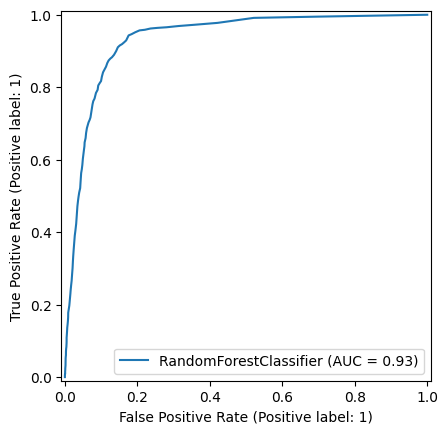

In [53]:
# Plot the ROC curve directly from the estimator
RocCurveDisplay.from_estimator(rf, X_test, y_test)
plt.show()

## Post-processing

In [55]:
# Tune the threshold

probs = rf.predict_proba(X_test)[:,1]

thresholds = np.arange(0.1,0.9,0.05)
f1_scores = [f1_score(y_test, probs > t) for t in thresholds]

best_threshold = np.round(thresholds[np.argmax(f1_scores)],3)

In [56]:
best_threshold

np.float64(0.4)

In [57]:
# Use the new threshold to reassign outcome
predicted_proba = rf.predict_proba(X_test)
y_pred_new = (predicted_proba [:,1] >= best_threshold).astype('int')

In [58]:
confusion_matrix(y_test, y_pred_new)

array([[6937,  484],
       [ 172,  407]])

In [59]:
print(classification_report(y_test, y_pred_new))

              precision    recall  f1-score   support

           0       0.98      0.93      0.95      7421
           1       0.46      0.70      0.55       579

    accuracy                           0.92      8000
   macro avg       0.72      0.82      0.75      8000
weighted avg       0.94      0.92      0.93      8000



Lowering the threshold leads to increase in true positives, which means better recall. However, it also leads to increase in false positives, which means worse precision.

In [61]:
# Get customer probabilities

term_dep_original["response_probability"] = rf.predict_proba(X)[:, 1]
term_dep_original.sort_values("response_probability", ascending=False).head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y,response_probability
39947,54,management,married,primary,no,2587,no,no,cellular,2,jun,236,2,yes,1.0
32005,44,self-employed,single,tertiary,no,1367,yes,no,cellular,13,apr,1232,3,yes,1.0
14638,45,blue-collar,divorced,primary,no,-207,no,no,cellular,15,jul,878,2,yes,1.0
39172,29,admin,single,secondary,no,306,yes,no,cellular,18,may,774,4,yes,1.0
32305,30,management,single,tertiary,no,424,no,no,cellular,16,apr,298,4,yes,1.0


In [62]:
# Select most likely customers to purchase term deposit (probability >= 90%)

top_segment = term_dep_original[term_dep_original["response_probability"]>=0.9]
top_segment.describe()

,age,balance,day,duration,campaign,response_probability
count,892.000000,892.000000,892.000000,892.000000,892.000000,892.000000
mean,39.306054,1537.530269,15.920404,765.786996,2.265695,0.948139
std,11.190898,2716.282497,8.674132,407.513629,1.993263,0.032316
min,19.000000,-930.000000,1.000000,97.000000,1.000000,0.900000
25%,31.000000,221.250000,8.000000,471.500000,1.000000,0.920000
50%,36.000000,663.000000,15.000000,739.500000,2.000000,0.950000
75%,46.000000,1928.500000,22.000000,1008.750000,3.000000,0.980000
max,95.000000,34646.000000,31.000000,2456.000000,21.000000,1.000000


The customers with very high probability of purchasing a term deposit are about 2.2% of the total customer population

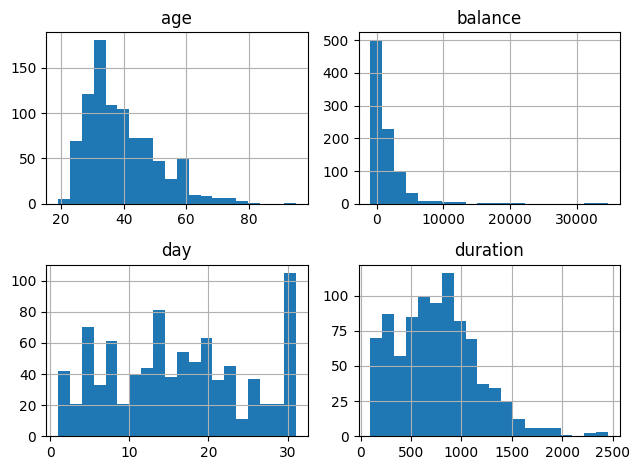

In [64]:
top_segment[num_cols].hist(bins=20)
plt.tight_layout()
plt.show()

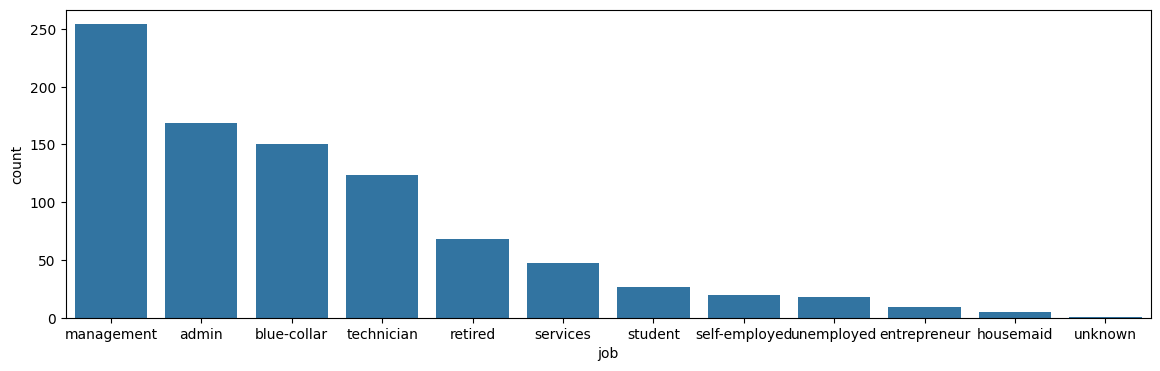

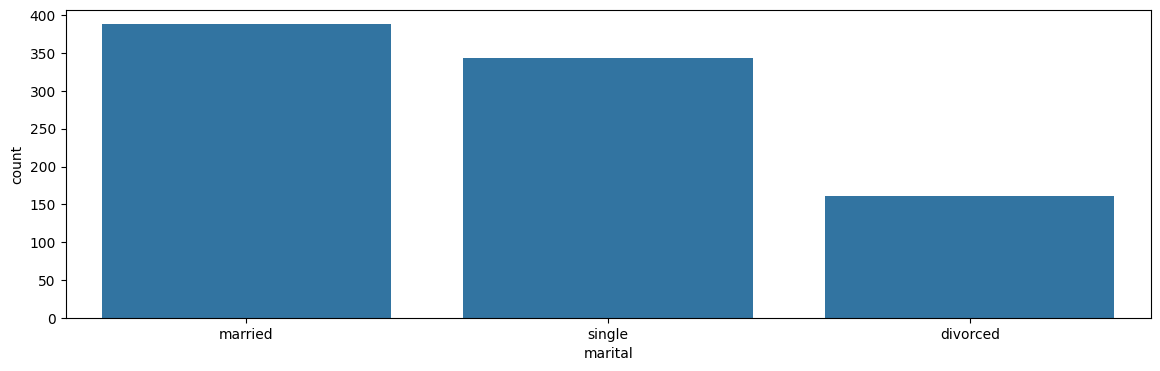

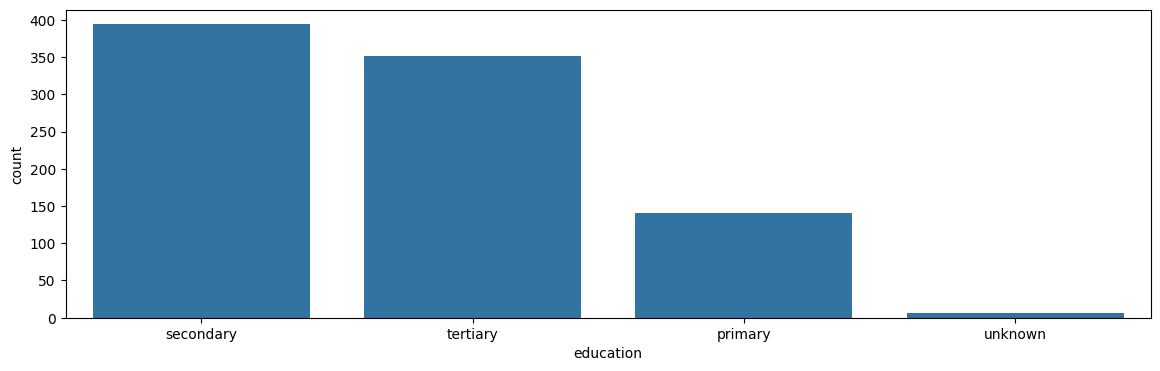

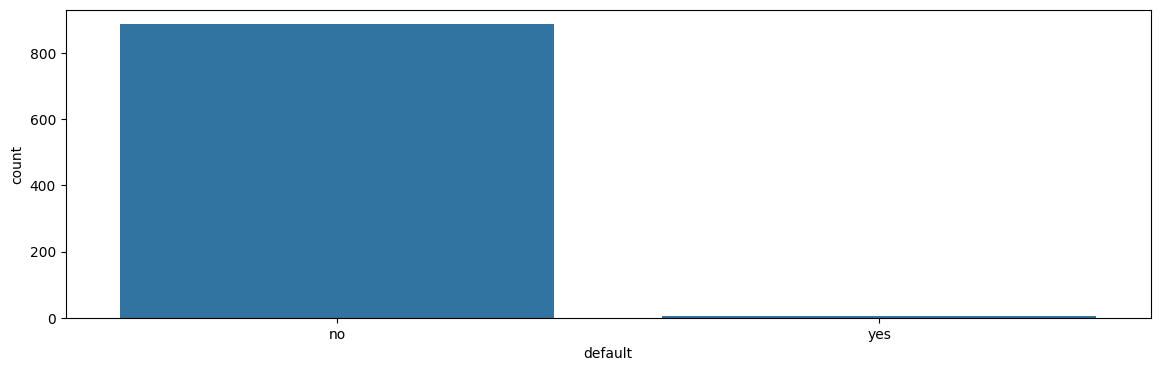

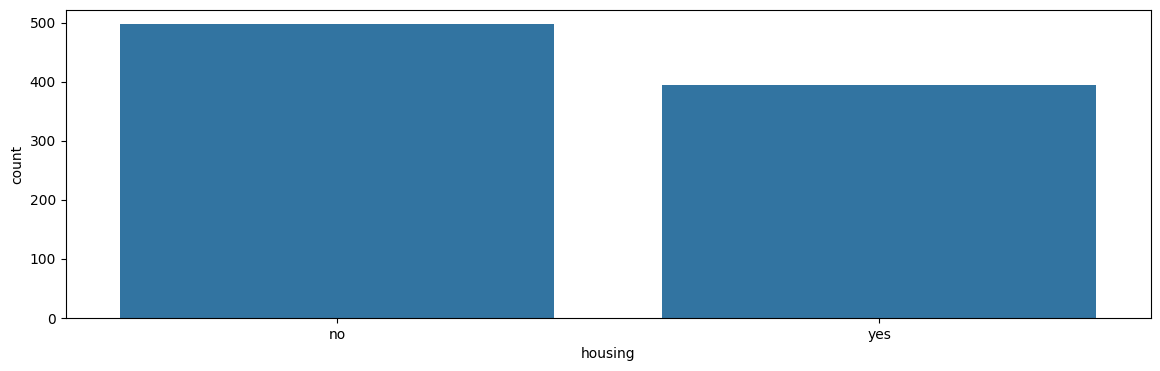

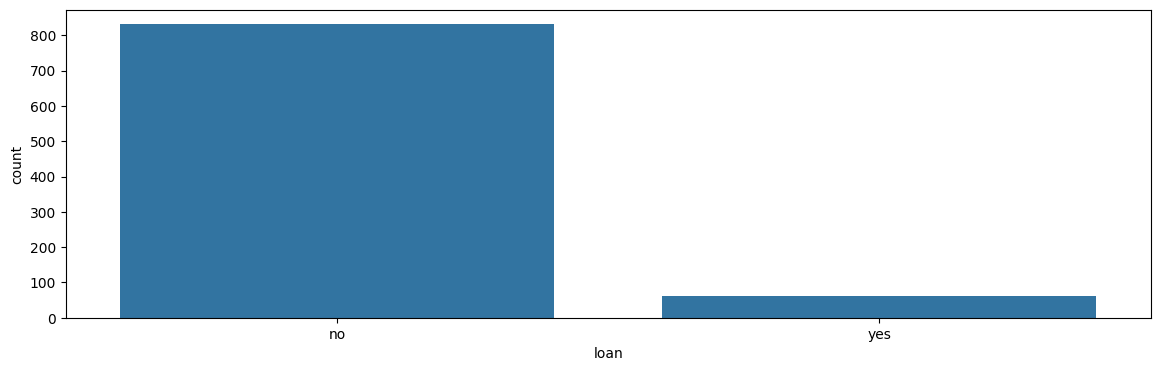

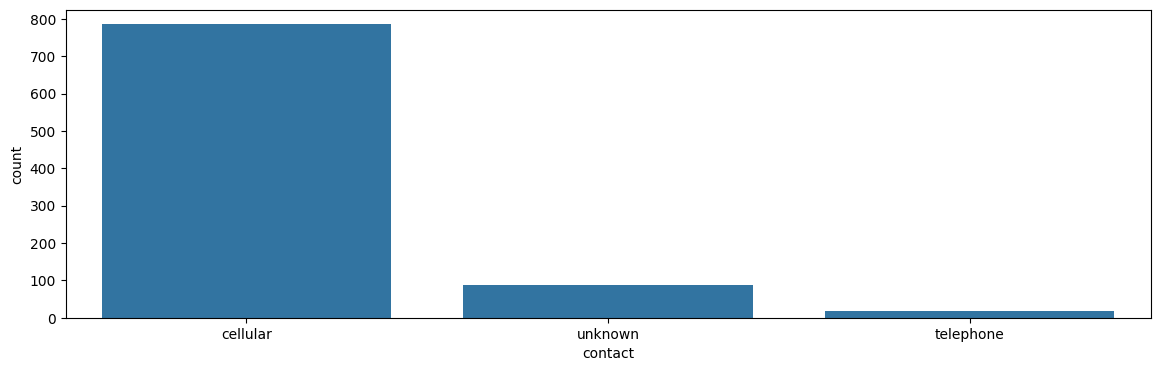

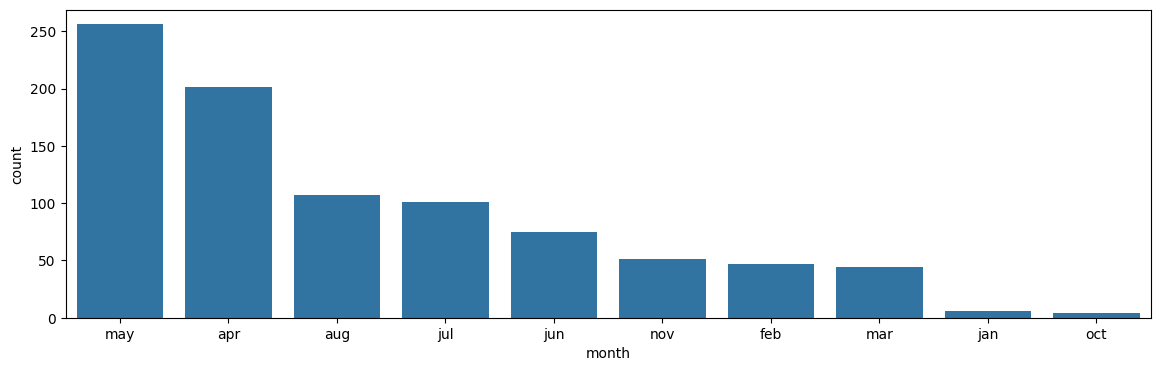

In [65]:
for col in cat_cols:
    plt.figure(figsize=(14,4))
    sns.countplot(x=col, data=top_segment, order=top_segment[col].value_counts().index)
    plt.show()

#### Customers who are more likely to purchase term deposit have the following characteristics:
1. A large majority of them made the decision between months April and August (in Spring and Summer seasons)
2. They were contacted on their cellular phones
3. They do not have personal loan
4. They may or may not have housing loan
5. They do not have a credit in default
6. They are likely to have received secondary or higher education
7. Married and single customers are more likely to say yes than those who are divorced
8. A large majority of them are employed by others
9. A large majority of them are in 25-60 age range
10. A large majority of them have yearly account balance of <50,000. Some of them have a negative balance as well.
11. An unusual number of customers purchased term deposit on the last day of month
12. If a customer remained on the call for longer than 15 minutes, they were less likely to purchase term deposit.

In [67]:
feat_imp = pd.DataFrame(rf.feature_importances_, columns = ["feature importance"], index = X.columns)
feat_imp.sort_values(by = "feature importance", ascending=False)

,feature importance
duration_log,0.424530
balance_qt,0.071896
age,0.067367
day,0.067215
contact_unknown,0.045730
housing_yes,0.035583
month_aug,0.027026
month_jul,0.025517
marital_married,0.022998
loan_yes,0.021211


#### The most important features in this dataset are:
1. Duration
2. Balance
3. Day (of the month), and
4. Age (of customer)

It is advised to neglect contact method = 'unknown' as very few customers have conatct method unknown.